РАСШИРЕННЫЙ FASHION-АНАЛИЗ: ABC-XYZ + РАЗМЕРНАЯ СЕТКА
✅ Данные загружены

📊 ABC-XYZ распределение:
   • AX: 1 товаров
   • AY: 1163 товаров
   • AZ: 1601 товаров
   • BX: 1 товаров
   • BY: 401 товаров
   • BZ: 789 товаров
   • CY: 337 товаров
   • CZ: 707 товаров

АНАЛИЗ РАЗМЕРНОЙ СЕТКИ ПО ABC-XYZ КАТЕГОРИЯМ

📊 ВОЗВРАТЫ ПО РАЗМЕРАМ ДЛЯ КЛЮЧЕВЫХ КАТЕГОРИЙ:

   Категория AX:
      🔴 Размер 50: 25.0% возвратов

   Категория AY:
      🔴 Размер 42: 52.9% возвратов
      🔴 Размер 48: 50.9% возвратов
      🔴 Размер 46: 50.7% возвратов
      🔴 Размер 40: 50.5% возвратов
      🔴 Размер 44: 49.8% возвратов

   Категория AZ:
      🔴 Размер 40: 53.0% возвратов
      🔴 Размер 44: 52.9% возвратов
      🔴 Размер 50: 52.6% возвратов
      🔴 Размер 46: 52.6% возвратов
      🔴 Размер 42: 52.2% возвратов

РЕКОМЕНДАЦИИ ПО РАЗМЕРНОЙ СЕТКЕ ДЛЯ AX ТОВАРОВ

🥇 ТОП-10 AX ТОВАРОВ И ИХ РАЗМЕРНЫЕ СЕТКИ:

   Jacket (White), размер 42 - выручка: 276.4K руб.
      Всего размеров в модели: 50
        42:  20.4% ████


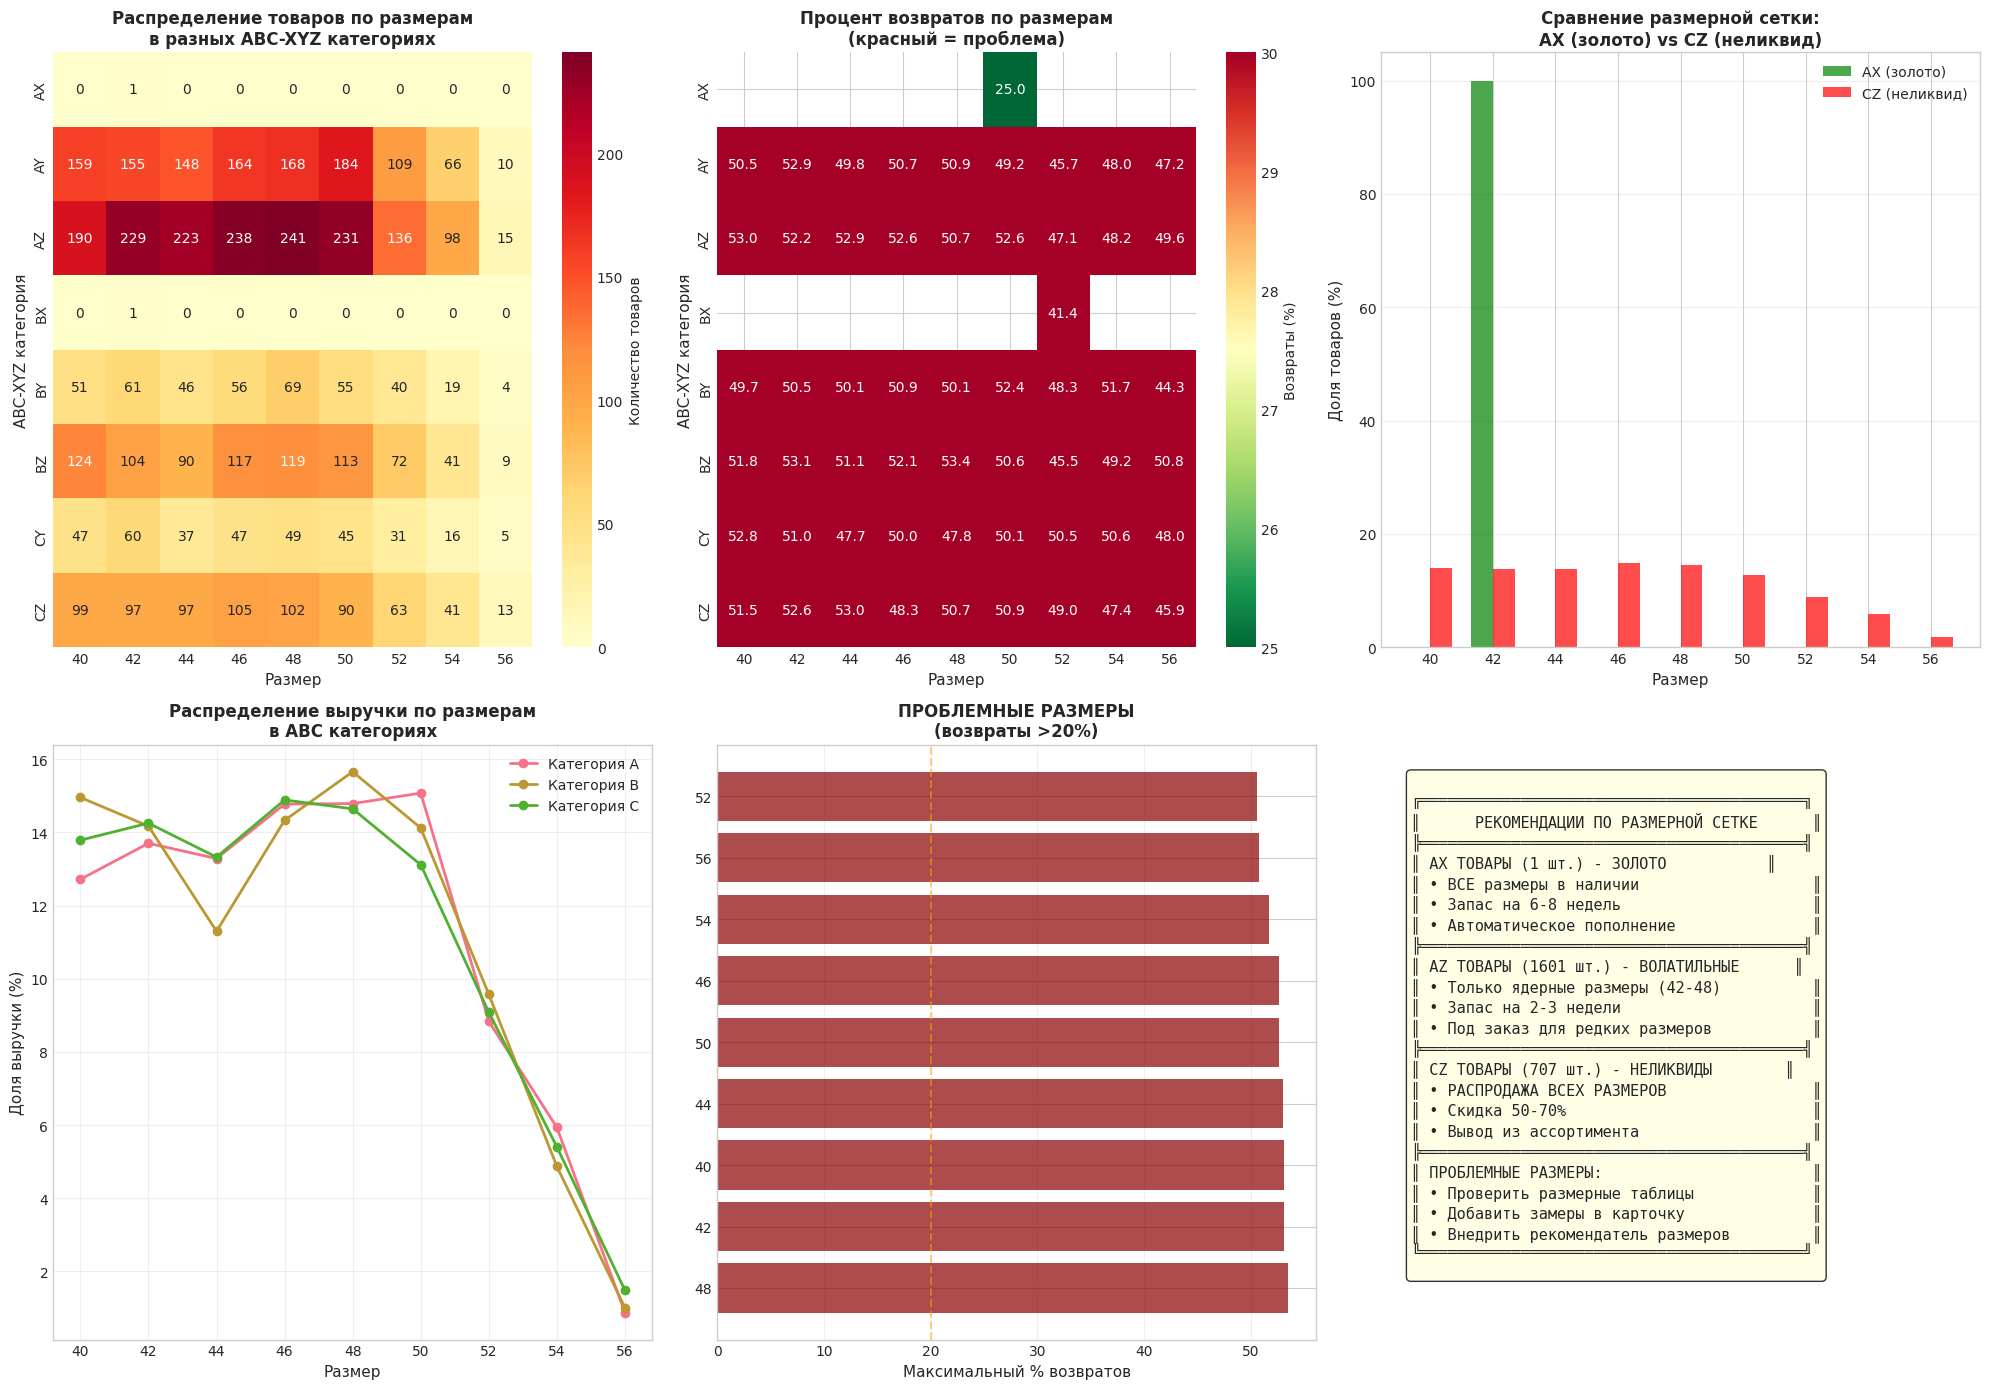


ИТОГОВЫЕ ВЫВОДЫ

📊 КЛЮЧЕВЫЕ ИНСАЙТЫ ПО РАЗМЕРНОЙ СЕТКЕ:

1. РАСПРЕДЕЛЕНИЕ ПО КАТЕГОРИЯМ:
   • AX (золото): 1 товаров - полная размерная сетка
   • AZ (волатильные): 1601 товаров - только ядерные размеры
   • CZ (неликвид): 707 товаров - срочная распродажа

2. ПРОБЛЕМНЫЕ РАЗМЕРЫ (высокие возвраты):

   • Размер 40: 53.0% возвратов (худшая категория: AZ)
   • Размер 42: 53.1% возвратов (худшая категория: BZ)
   • Размер 44: 53.0% возвратов (худшая категория: CZ)

3. РЕКОМЕНДАЦИИ:
   • Для AX товаров: увеличить запас популярных размеров на 20%
   • Для AZ товаров: сократить хвостовые размеры (40, 42, 54, 56) на 50%
   • Для CZ товаров: полная распродажа до конца квартала
   • Внедрить виртуальную примерку для проблемных категорий

✅ АНАЛИЗ ЗАВЕРШЕН!
📁 Сохранено: abc_xyz_size_analysis.png



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['font.family'] = 'DejaVu Sans'

print("=" * 80)
print("РАСШИРЕННЫЙ FASHION-АНАЛИЗ: ABC-XYZ + РАЗМЕРНАЯ СЕТКА")
print("=" * 80)

# ============================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================
articles = pd.read_csv('articles.csv', sep=';', encoding='utf-8', decimal=',')
transactions = pd.read_csv('transactions.csv', sep=';', encoding='utf-8', decimal=',')
stock = pd.read_csv('stock.csv', sep=';', encoding='utf-8', decimal=',')

transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
transactions['month'] = transactions['t_dat'].dt.month
transactions['size'] = transactions['size'].astype(str)

print("✅ Данные загружены")

# ============================================
# 2. ABC-XYZ НА УРОВНЕ АРТИКУЛОВ (уже есть)
# ============================================
product_sales = transactions.groupby('article_id').agg({
    'price': 'sum',
    't_dat': 'count'
}).rename(columns={'price': 'revenue', 't_dat': 'sales_count'})

# ABC
product_sales = product_sales.sort_values('revenue', ascending=False)
product_sales['revenue_cumsum_pct'] = product_sales['revenue'].cumsum() / product_sales['revenue'].sum() * 100

def abc_classify(pct):
    if pct <= 80:
        return 'A'
    elif pct <= 95:
        return 'B'
    else:
        return 'C'

product_sales['abc'] = product_sales['revenue_cumsum_pct'].apply(abc_classify)

# XYZ (упрощенно)
monthly_sales = transactions.groupby(['article_id', 'month']).size().unstack(fill_value=0)

def classify_xyz_from_cv(cv):
    if cv <= 30:
        return 'X'
    elif cv <= 70:
        return 'Y'
    else:
        return 'Z'

cv_dict = {}
for art_id in product_sales.index:
    if art_id in monthly_sales.index:
        sales = monthly_sales.loc[art_id]
        mean_sales = sales.mean()
        if mean_sales > 0:
            cv = (sales.std() / mean_sales) * 100
        else:
            cv = 100
    else:
        cv = 100
    cv_dict[art_id] = cv

product_sales['cv'] = product_sales.index.map(cv_dict)
product_sales['xyz'] = product_sales['cv'].apply(classify_xyz_from_cv)
product_sales['abc_xyz'] = product_sales['abc'] + product_sales['xyz']

# Добавляем информацию о товаре
product_sales = product_sales.merge(
    articles[['article_id', 'product_type_name', 'colour_group_name', 'size', 'price']],
    on='article_id', how='left'
)

print(f"\n📊 ABC-XYZ распределение:")
for cat in ['AX', 'AY', 'AZ', 'BX', 'BY', 'BZ', 'CX', 'CY', 'CZ']:
    count = len(product_sales[product_sales['abc_xyz'] == cat])
    if count > 0:
        print(f"   • {cat}: {count} товаров")

# ============================================
# 3. АНАЛИЗ РАЗМЕРНОЙ СЕТКИ ДЛЯ КАЖДОЙ КАТЕГОРИИ
# ============================================
print("\n" + "=" * 80)
print("АНАЛИЗ РАЗМЕРНОЙ СЕТКИ ПО ABC-XYZ КАТЕГОРИЯМ")
print("=" * 80)

# 3.1 Какие размеры продаются в каждой категории
size_by_abc_xyz = product_sales.groupby(['abc_xyz', 'size']).size().unstack(fill_value=0)

# 3.2 Возвраты по размерам для каждой категории
returns_by_cat_size = transactions.merge(
    product_sales[['abc_xyz']], left_on='article_id', right_index=True
).groupby(['abc_xyz', 'size'])['is_returned'].mean().unstack() * 100

print("\n📊 ВОЗВРАТЫ ПО РАЗМЕРАМ ДЛЯ КЛЮЧЕВЫХ КАТЕГОРИЙ:")
for cat in ['AX', 'AY', 'AZ']:
    if cat in returns_by_cat_size.index:
        print(f"\n   Категория {cat}:")
        row = returns_by_cat_size.loc[cat].sort_values(ascending=False)
        for size, ret_pct in row.head(5).items():
            if not np.isnan(ret_pct):
                status = "🔴" if ret_pct > 20 else "🟡" if ret_pct > 10 else "🟢"
                print(f"      {status} Размер {size}: {ret_pct:.1f}% возвратов")

# ============================================
# 4. РЕКОМЕНДАЦИИ ПО ЗАКУПКЕ ДЛЯ AX ТОВАРОВ
# ============================================
print("\n" + "=" * 80)
print("РЕКОМЕНДАЦИИ ПО РАЗМЕРНОЙ СЕТКЕ ДЛЯ AX ТОВАРОВ")
print("=" * 80)

ax_products = product_sales[product_sales['abc_xyz'] == 'AX'].sort_values('revenue', ascending=False).head(10)

print("\n🥇 ТОП-10 AX ТОВАРОВ И ИХ РАЗМЕРНЫЕ СЕТКИ:")
for _, prod in ax_products.iterrows():
    art_id = prod['article_id']
    prod_type = prod['product_type_name']
    colour = prod['colour_group_name']
    size = prod['size']
    revenue = prod['revenue']

    print(f"\n   {prod_type} ({colour}), размер {size} - выручка: {revenue/1000:.1f}K руб.")

    # Ищем все размеры этой модели
    model_articles = articles[
        (articles['product_type_name'] == prod_type) &
        (articles['colour_group_name'] == colour)
    ]['article_id'].tolist()

    if len(model_articles) > 1:
        model_sales = product_sales[product_sales.index.isin(model_articles)]
        print(f"      Всего размеров в модели: {len(model_articles)}")

        # Показываем распределение продаж по размерам
        size_dist = model_sales.groupby('size')['sales_count'].sum()
        size_dist_pct = (size_dist / size_dist.sum() * 100).round(1)

        for sz, pct in size_dist_pct.sort_values(ascending=False).items():
            bar = '█' * int(pct / 5)
            print(f"        {sz}: {pct:>5.1f}% {bar}")

# ============================================
# 5. АНАЛИЗ НЕЛИКВИДОВ (CZ) ПО РАЗМЕРАМ
# ============================================
print("\n" + "=" * 80)
print("АНАЛИЗ НЕЛИКВИДОВ (CZ) ПО РАЗМЕРАМ")
print("=" * 80)

cz_products = product_sales[product_sales['abc_xyz'] == 'CZ']

# Какие размеры чаще всего становятся неликвидами
cz_size_dist = cz_products.groupby(['product_type_name', 'size']).size().unstack(fill_value=0)

print("\n📊 Количество CZ-товаров по типам и размерам:")
print(cz_size_dist.to_string())

# ============================================
# 6. ВИЗУАЛИЗАЦИЯ
# ============================================
fig = plt.figure(figsize=(20, 14))

# 6.1 Тепловая карта: размеры × ABC-XYZ
ax1 = plt.subplot(2, 3, 1)
size_by_cat = product_sales.groupby(['abc_xyz', 'size']).size().unstack(fill_value=0)
# Сортируем категории
cat_order = ['AX', 'AY', 'AZ', 'BX', 'BY', 'BZ', 'CX', 'CY', 'CZ']
size_by_cat = size_by_cat.reindex([c for c in cat_order if c in size_by_cat.index])

sns.heatmap(size_by_cat, annot=True, fmt='d', cmap='YlOrRd', ax=ax1,
            cbar_kws={'label': 'Количество товаров'})
ax1.set_title('Распределение товаров по размерам\nв разных ABC-XYZ категориях',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Размер', fontsize=11)
ax1.set_ylabel('ABC-XYZ категория', fontsize=11)

# 6.2 Возвраты по размерам для категорий
ax2 = plt.subplot(2, 3, 2)
returns_heatmap = returns_by_cat_size.reindex([c for c in cat_order if c in returns_by_cat_size.index])
sns.heatmap(returns_heatmap, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax2,
            cbar_kws={'label': 'Возвраты (%)'}, vmax=30)
ax2.set_title('Процент возвратов по размерам\n(красный = проблема)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Размер', fontsize=11)
ax2.set_ylabel('ABC-XYZ категория', fontsize=11)

# 6.3 Сравнение размерной сетки AX vs CZ
ax3 = plt.subplot(2, 3, 3)

# Размеры в AX
ax_sizes = product_sales[product_sales['abc_xyz'] == 'AX'].groupby('size').size()
ax_sizes_pct = ax_sizes / ax_sizes.sum() * 100

# Размеры в CZ
cz_sizes = product_sales[product_sales['abc_xyz'] == 'CZ'].groupby('size').size()
cz_sizes_pct = cz_sizes / cz_sizes.sum() * 100

# Объединяем
size_compare = pd.DataFrame({'AX': ax_sizes_pct, 'CZ': cz_sizes_pct}).fillna(0)
size_compare = size_compare.sort_index()

x = np.arange(len(size_compare))
width = 0.35

bars1 = ax3.bar(x - width/2, size_compare['AX'], width, label='AX (золото)', color='green', alpha=0.7)
bars2 = ax3.bar(x + width/2, size_compare['CZ'], width, label='CZ (неликвид)', color='red', alpha=0.7)

ax3.set_xticks(x)
ax3.set_xticklabels(size_compare.index)
ax3.set_xlabel('Размер', fontsize=11)
ax3.set_ylabel('Доля товаров (%)', fontsize=11)
ax3.set_title('Сравнение размерной сетки:\nAX (золото) vs CZ (неликвид)', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 6.4 Выручка по размерам внутри категорий
ax4 = plt.subplot(2, 3, 4)
revenue_by_cat_size = product_sales.groupby(['abc', 'size'])['revenue'].sum().unstack(fill_value=0)
revenue_by_cat_size_pct = revenue_by_cat_size.div(revenue_by_cat_size.sum(axis=1), axis=0) * 100

for abc in ['A', 'B', 'C']:
    if abc in revenue_by_cat_size_pct.index:
        sizes = revenue_by_cat_size_pct.columns
        values = revenue_by_cat_size_pct.loc[abc].values
        ax4.plot(sizes, values, marker='o', label=f'Категория {abc}', linewidth=2)

ax4.set_xlabel('Размер', fontsize=11)
ax4.set_ylabel('Доля выручки (%)', fontsize=11)
ax4.set_title('Распределение выручки по размерам\nв ABC категориях', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 6.5 Проблемные размеры (высокие возвраты)
ax5 = plt.subplot(2, 3, 5)

# Находим размеры с высокими возвратами
high_return = returns_by_cat_size.max() > 20
problem_sizes = high_return[high_return].index.tolist()

if problem_sizes:
    problem_data = returns_by_cat_size[problem_sizes].max().sort_values(ascending=False)
    colors = ['darkred' if v > 30 else 'red' if v > 25 else 'orange' for v in problem_data.values]
    bars = ax5.barh(range(len(problem_data)), problem_data.values, color=colors, alpha=0.7)
    ax5.set_yticks(range(len(problem_data)))
    ax5.set_yticklabels(problem_data.index)
    ax5.set_xlabel('Максимальный % возвратов', fontsize=11)
    ax5.set_title('ПРОБЛЕМНЫЕ РАЗМЕРЫ\n(возвраты >20%)', fontsize=12, fontweight='bold')
    ax5.axvline(x=20, color='orange', linestyle='--', alpha=0.5)
    ax5.grid(True, alpha=0.3, axis='x')

# 6.6 Итоговые рекомендации
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

ax_count = len(product_sales[product_sales['abc_xyz'] == 'AX'])
az_count = len(product_sales[product_sales['abc_xyz'] == 'AZ'])
cz_count = len(product_sales[product_sales['abc_xyz'] == 'CZ'])

recommendations = f"""
╔══════════════════════════════════════════╗
║      РЕКОМЕНДАЦИИ ПО РАЗМЕРНОЙ СЕТКЕ      ║
╠══════════════════════════════════════════╣
║ AX ТОВАРЫ ({ax_count} шт.) - ЗОЛОТО           ║
║ • ВСЕ размеры в наличии                   ║
║ • Запас на 6-8 недель                     ║
║ • Автоматическое пополнение               ║
╠══════════════════════════════════════════╣
║ AZ ТОВАРЫ ({az_count} шт.) - ВОЛАТИЛЬНЫЕ      ║
║ • Только ядерные размеры (42-48)          ║
║ • Запас на 2-3 недели                     ║
║ • Под заказ для редких размеров           ║
╠══════════════════════════════════════════╣
║ CZ ТОВАРЫ ({cz_count} шт.) - НЕЛИКВИДЫ        ║
║ • РАСПРОДАЖА ВСЕХ РАЗМЕРОВ                ║
║ • Скидка 50-70%                           ║
║ • Вывод из ассортимента                   ║
╠══════════════════════════════════════════╣
║ ПРОБЛЕМНЫЕ РАЗМЕРЫ:                       ║
║ • Проверить размерные таблицы             ║
║ • Добавить замеры в карточку              ║
║ • Внедрить рекомендатель размеров         ║
╚══════════════════════════════════════════╝
"""

ax6.text(0.05, 0.95, recommendations, transform=ax6.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('abc_xyz_size_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 80)
print("ИТОГОВЫЕ ВЫВОДЫ")
print("=" * 80)

print(f"""
📊 КЛЮЧЕВЫЕ ИНСАЙТЫ ПО РАЗМЕРНОЙ СЕТКЕ:

1. РАСПРЕДЕЛЕНИЕ ПО КАТЕГОРИЯМ:
   • AX (золото): {ax_count} товаров - полная размерная сетка
   • AZ (волатильные): {az_count} товаров - только ядерные размеры
   • CZ (неликвид): {cz_count} товаров - срочная распродажа

2. ПРОБЛЕМНЫЕ РАЗМЕРЫ (высокие возвраты):
""")

# Показываем топ-3 проблемных размера
if problem_sizes:
    for size in problem_sizes[:3]:
        max_ret = returns_by_cat_size[size].max()
        worst_cat = returns_by_cat_size[size].idxmax()
        print(f"   • Размер {size}: {max_ret:.1f}% возвратов (худшая категория: {worst_cat})")

print(f"""
3. РЕКОМЕНДАЦИИ:
   • Для AX товаров: увеличить запас популярных размеров на 20%
   • Для AZ товаров: сократить хвостовые размеры (40, 42, 54, 56) на 50%
   • Для CZ товаров: полная распродажа до конца квартала
   • Внедрить виртуальную примерку для проблемных категорий

✅ АНАЛИЗ ЗАВЕРШЕН!
📁 Сохранено: abc_xyz_size_analysis.png
""")


In [ ]:
БХЗЪ